In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
asbestos = pd.read_csv("asbestos.csv")

In [2]:
asbestosSorted = asbestos.sort_values(by ='city')

In [3]:
quantity = asbestosSorted['city'].value_counts()
total = asbestosSorted.drop(columns =['s_name','s_address', 'z_code', 'p_fee', 'c_number',
                                      'contractor', 'permit_specifications',
                                      'i_date', 'e_date', 'achd_inspector', 'job_complete',
                                      'is_permit_date_extended','permit_o_e_date','project_type',
                                      'latitude', 'longitude'])
#totQuant= total.groupby(by=['city']).count()
#totQuant['quantity'] = quantity

In [4]:
options = ['BRADDOCK', 'CLAIRTON', 'NORTH FAYETTE', 
           'NORTH BRADDOCK', 'RANKIN', 'MCKEESPORT', 
           'WILKINSBURG', 'FORWARD', 'WILMERDING', 'DUQUENSE', 
           'HOMESTEAD', 'FRAZER TOWNSHIP', 'HARRISON TOWNSHIP', 
           'SPRING GARDEN', 'TURTLE CREEK', 'ETNA'] 
  
# selecting rows based on condition 
newDF = total[total['city'].isin(options)] 


In [5]:

newDF

,permit_number,city,square_feet,is_the_building_occupied
226,PAA190693,BRADDOCK,202,f
111,PAA190244,BRADDOCK,4152,f
300,PAA194165,BRADDOCK,1504,f
251,PAA192005,BRADDOCK,2000,t
298,PAA194126,BRADDOCK,3500,f
41,PAA180656,CLAIRTON,6600,f
311,PAA194424,CLAIRTON,1625,f
250,PAA192004,CLAIRTON,9000,t
68,PAA190055,CLAIRTON,900,f
35,PAA180650,CLAIRTON,15700,f


In [6]:
totQuant= newDF.groupby(by=['city']).mean()
totQuant['quantity'] = quantity
#totQuant=totQuant.drop(columns=['permit_number', 'is_the_building_occupied'])
totQuant



,square_feet,quantity
city,,
BRADDOCK,2271.600000,5
CLAIRTON,6744.454545,22
ETNA,7517.500000,2
HOMESTEAD,1353.444444,9
MCKEESPORT,2655.588235,17
WILMERDING,18440.000000,1


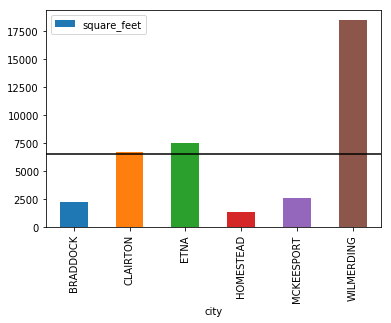

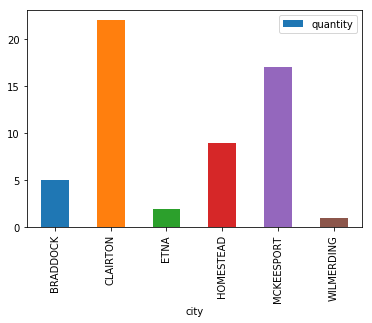

In [7]:
asbestosSqFtAvg = totQuant.plot.bar(y = 'square_feet')
plt.axhline(totQuant['square_feet'].mean(), color='k');

asbestosQuant = totQuant.plot.bar(y = 'quantity')


,Asbestos Metric
city,
CLAIRTON,1.000000
MCKEESPORT,0.304257
WILMERDING,0.124277
ETNA,0.101329
HOMESTEAD,0.082094
BRADDOCK,0.076548


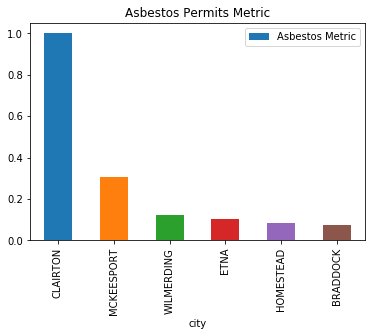

In [10]:
totQuant['Asbestos Metric'] = totQuant['square_feet']*totQuant['quantity']
maxPercent = totQuant['Asbestos Metric'].max()

asbestosMetric = totQuant.divide(maxPercent).drop(columns = ['square_feet','quantity']).sort_values(['Asbestos Metric'], ascending=False)
#poorConMetric

#display(valueCompare['PoorConditionMetric'])
display(asbestosMetric)

asbestosMetricGraph = asbestosMetric.plot.bar(y = 'Asbestos Metric', title='Asbestos Permits Metric')
